In [1]:
%load_ext autoreload
%autoreload 2

from tasks.math_ops.xpy_t2 import xpy_t2_task, sample_xpy_t2_problem

nnsight is not detected. Please install via 'pip install nnsight' for nnsight backend.


In [2]:
# Load LM
from neural.pipeline import LMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "allenai/OLMo-2-0425-1B" # "Qwen/Qwen2.5-0.5B"
pipeline = LMPipeline(model_name, max_new_tokens=1, device=device, dtype=torch.bfloat16, max_length=32)
pipeline.tokenizer.padding_side = "left"

def checker(neural_output, causal_output):
    return causal_output in neural_output["string"] or neural_output["string"] in causal_output

print("DEVICE:", pipeline.model.device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

DEVICE: cuda:0


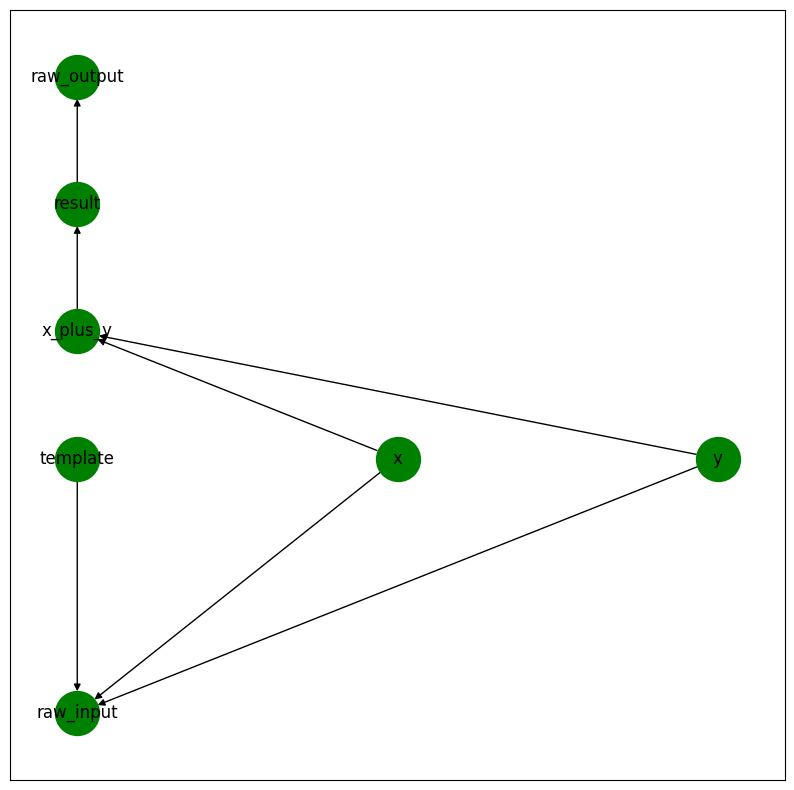

In [3]:
# Define causal model
causal_model = xpy_t2_task.causal_models["xpy_t2"]
causal_model.print_structure()

In [4]:
# Confirm interchange intervention works as expected
example = sample_xpy_t2_problem()
full_setting = causal_model.run_forward(example)
new_example = sample_xpy_t2_problem()
new_full_setting = causal_model.run_forward(new_example)

x0, y0 = example["x"], example["y"]
print(f"Original is ({x0} + {y0}) * 2  =  {(x0+y0)*2}")

x1, y1 = new_example["x"], new_example["y"]
print(f"New one  is ({x1} + {y1}) * 2  =  {(x1+y1)*2}")
print()
print(f"Intervention should be ({x1} + {y0}) * 2  =  {(x1+y0)*2}")

intervened_full_setting = causal_model.run_interchange(example, {"x": new_example})
intervened_full_setting

Original is (9 + 5) * 2  =  28
New one  is (6 + 4) * 2  =  20

Intervention should be (6 + 5) * 2  =  22


defaultdict(None,
            {'template': '<|endoftext|>, Yes, (<x> + <y>) * 2 = ',
             'x': 6,
             'y': 5,
             'x_plus_y': 11,
             'result': 22,
             'raw_input': '<|endoftext|>, Yes, (9 + 5) * 2 = ',
             'raw_output': '22'})

Original:
Causal output is (13 + 7) * 2  =  40
Neural output is 26

Counterfactual:
Causal output is (12 + 11) * 2  =  46
Neural output is 44

Running SameLengthResidualStreamTracing experiment...


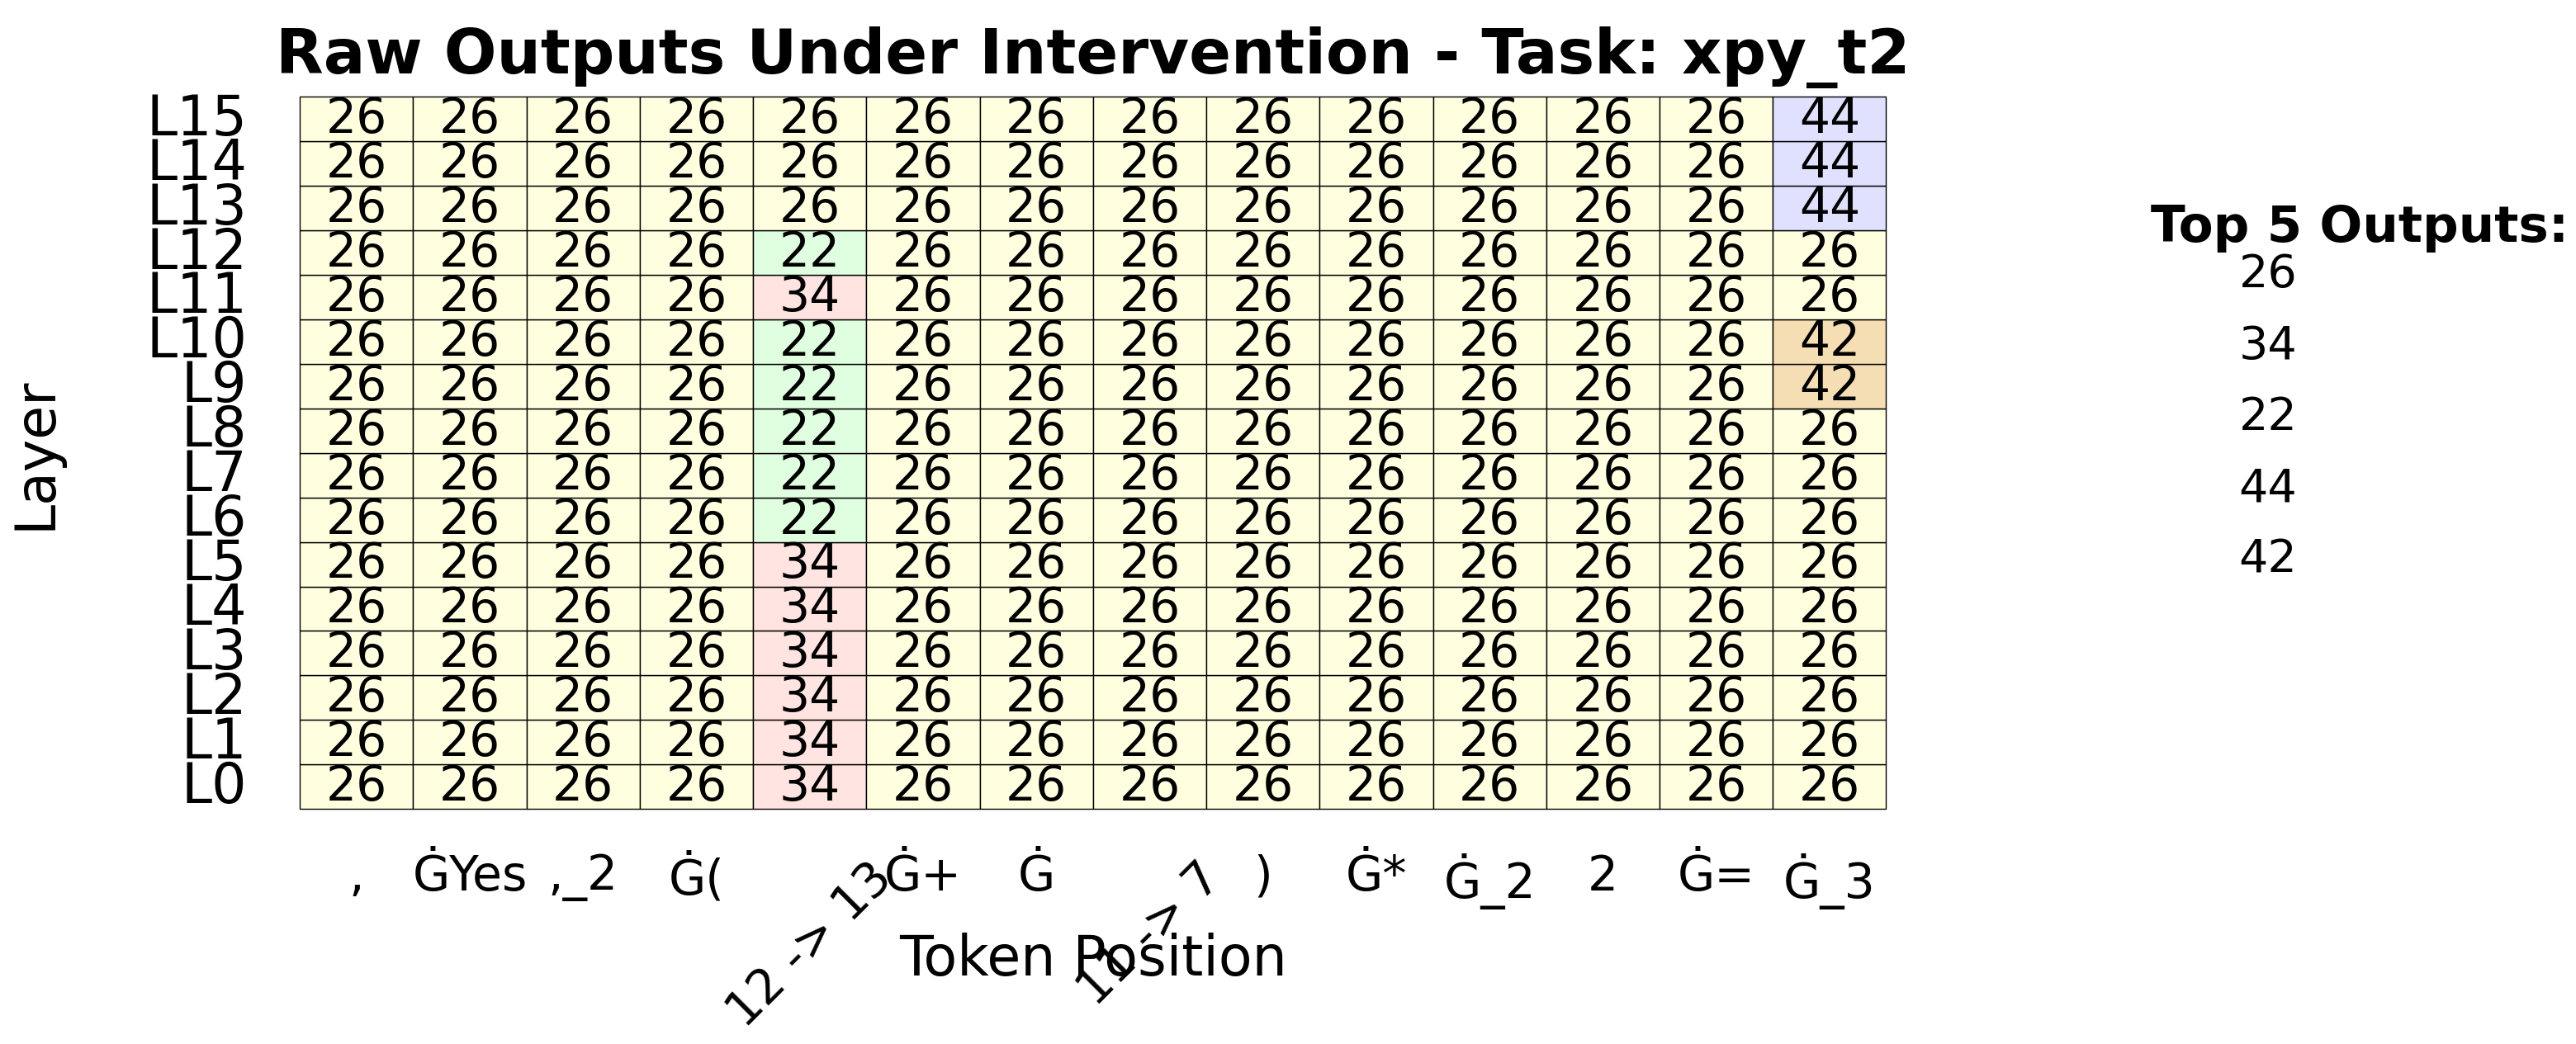


Tracing completed for 4 layer-position combinations


In [5]:
# Compare LM outputs for single pair intervention
# Takes about 35 seconds

# Import the tracing experiment
from experiments.LM_experiments.residual_stream_experiment import SameLengthResidualStreamTracing

original = sample_xpy_t2_problem()
counterfactual = sample_xpy_t2_problem()

x0, y0 = original["x"], original["y"]
neural_output = pipeline.generate(original["raw_input"])["string"]
print("Original:")
print(f"Causal output is ({x0} + {y0}) * 2  =  {(x0+y0)*2}")
print(f"Neural output is {neural_output}")

x1, y1 = counterfactual["x"], counterfactual["y"]
neural_output = pipeline.generate(counterfactual["raw_input"])["string"]
print("\nCounterfactual:")
print(f"Causal output is ({x1} + {y1}) * 2  =  {(x1+y1)*2}")
print(f"Neural output is {neural_output}")

# Run the tracing experiment
print("\n" + "="*50)
print("Running SameLengthResidualStreamTracing experiment...")
print("="*50)

# Create the tracing experiment
tracing_exp = SameLengthResidualStreamTracing(
    pipeline=pipeline,
    causal_model=causal_model,
    checker=checker,
)

# Run the experiment with our counterfactual pair
results = tracing_exp.run(
    base_input=original,
    counterfactual_input=counterfactual
)

tracing_exp.plot_raw_outputs(results, "./tracing_results/tracing_heatmap.png")
print(f"\nTracing completed for {len(results)} layer-position combinations")

In [9]:
# Compute interchange intervention accuracy
from causal.counterfactual_dataset import CounterfactualDataset
from experiments.LM_experiments.residual_stream_experiment import PatchResidualStream

size = 64
random_pairs = CounterfactualDataset.from_sampler(size, xpy_t2_task.dataset_generators["random_counterfactual"])
dataset = {"random_pairs": random_pairs}

token_positions = list(xpy_t2_task.create_token_positions(pipeline).values())

start = 0
end = pipeline.get_num_layers()
config = {"batch_size": 64}
target_variables_list  =  [["x"], ["y"], ["result"]]
results_dir = "vector_patching_results"

experiment = PatchResidualStream(pipeline, causal_model, list(range(start, end)), token_positions, checker, config=config)
raw_results = experiment.perform_interventions(dataset, verbose=True, target_variables_list=target_variables_list)

Running interventions: 100%|██████████| 48/48 [00:14<00:00,  3.22it/s, dataset=random_pairs, units=[[AtomicModelUnit(id='ResidualStream(Layer-15,Token-last_token)')]]]


vector_patching_results/heatmap_dataset_random_pairs_task_xpy_t2_variables_x.png


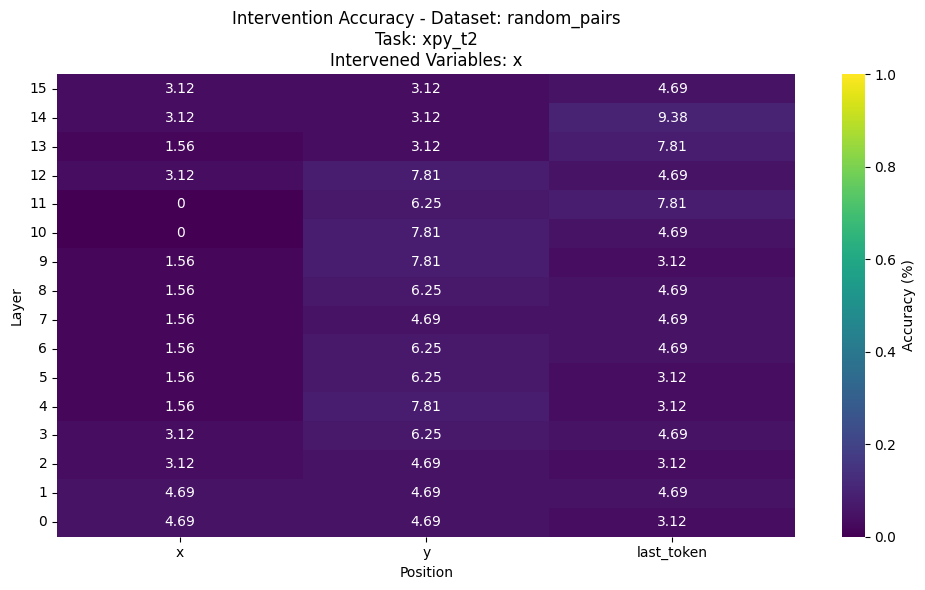

vector_patching_results/heatmap_dataset_random_pairs_task_xpy_t2_variables_y.png


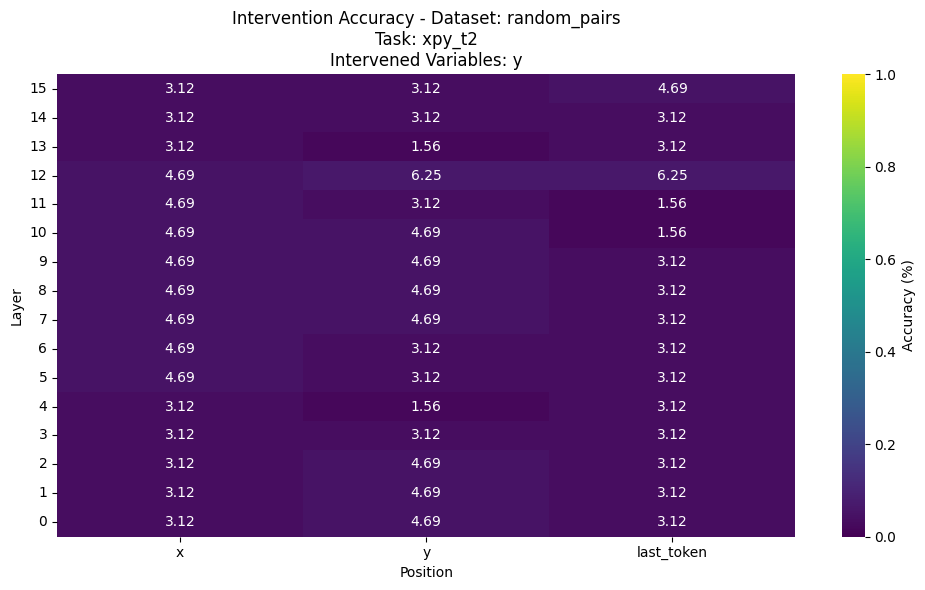

vector_patching_results/heatmap_dataset_random_pairs_task_xpy_t2_variables_result.png


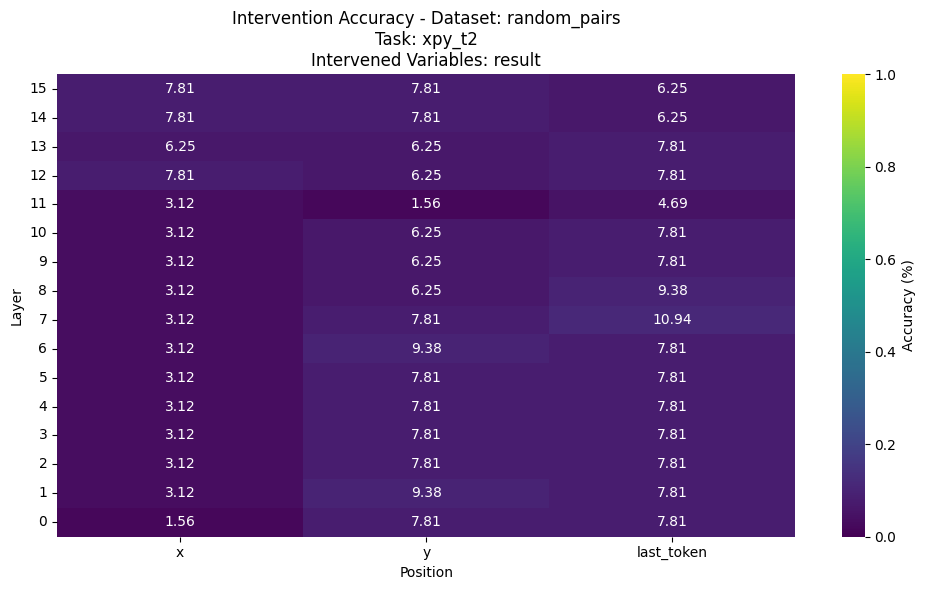

In [10]:
experiment.plot_heatmaps(raw_results, ["x"], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["y"], save_path=results_dir)
experiment.plot_heatmaps(raw_results, ["result"], save_path=results_dir)

In [8]:
# Now do DBM
from experiments.LM_experiments.attention_head_experiment import PatchAttentionHeads
from neural.LM_units import get_all_tokens, TokenPosition
from causal.counterfactual_dataset import CounterfactualDataset

results_dir = "DBM_results/"
num_heads = pipeline.get_num_attention_heads()
end = pipeline.get_num_layers()
target_variables_list  = [["result"]]
config = {
    "learning_rate": 0.001,
    "batch_size": 32,
    "evaluation_batch_size": 128, 
    "training_epoch": 20, 
    "masking":{"regularization_coefficient": 0.1},
    "featurizer_kwargs": {"tie_masks": True}
}

size = 64
random_pairs = CounterfactualDataset.from_sampler(size, addition_task.dataset_generators["distinct_counterfactual"])
train_set = {"random_pairs": random_pairs}
random_pairs = CounterfactualDataset.from_sampler(size, addition_task.dataset_generators["distinct_counterfactual"])
test_set = {"random_pairs": random_pairs}

target_variables = ["result"]

all_tokens = TokenPosition(lambda x: get_all_tokens(x, pipeline), pipeline, id="all_tokens")

heads_masking = [[(layer, head) for layer in range(0, end) for head in range(num_heads)]]

experiment = PatchAttentionHeads(pipeline, causal_model, heads_masking, all_tokens, checker, config=config)

experiment.train_interventions(train_set, target_variables, method="DBM", verbose=True)
raw_results = experiment.perform_interventions(train_set, verbose=True, target_variables_list=target_variables_list, save_dir=results_dir)
test_raw_results = experiment.perform_interventions(test_set, verbose=True, target_variables_list=target_variables_list, save_dir="test_" + results_dir)
print("TRAIN PERFORMANCE")
print(list(raw_results["dataset"]["random_pairs"]["model_unit"].values())[0]["result"]["average_score"])
print("TEST PERFORMANCE")
print(list(test_raw_results["dataset"]["random_pairs"]["model_unit"].values())[0]["result"]["average_score"])
experiment.plot_mask_heatmap(raw_results, save_path=results_dir)

# Took 2 min w/ batch 4
# Took 2 min w/ batch 32

NameError: name 'addition_task' is not defined